In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:\\Users\\Asus\\Downloads\\dataset pratices\\diabetes.csv')


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


What is the target variable in this dataset and what does it represent clinically?

ans: The target variable in this dataset is Outcome. It is a binary variable that represent an individual has diabetes or not.
A value 1 indicates diabetes and value 0 indicates not diabetes.

Clinically this variable represent the presence or absence of diabetes based on diagnostic creteria when data was collected


How many samples and features are present?

In [5]:
df.shape

(768, 9)

The dataset contain 768 number of patient and 8 are features and 1 is target variable, where target variable represent 
the status of daibetes

In [6]:
df. size

6912

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
for i in df.columns:
    if df[i].value_counts:
        print(df[i])
    
 
    

0       6
1       1
2       8
3       1
4       0
       ..
763    10
764     2
765     5
766     1
767     1
Name: Pregnancies, Length: 768, dtype: int64
0      148
1       85
2      183
3       89
4      137
      ... 
763    101
764    122
765    121
766    126
767     93
Name: Glucose, Length: 768, dtype: int64
0      72
1      66
2      64
3      66
4      40
       ..
763    76
764    70
765    72
766    60
767    70
Name: BloodPressure, Length: 768, dtype: int64
0      35
1      29
2       0
3      23
4      35
       ..
763    48
764    27
765    23
766     0
767    31
Name: SkinThickness, Length: 768, dtype: int64
0        0
1        0
2        0
3       94
4      168
      ... 
763    180
764      0
765    112
766      0
767      0
Name: Insulin, Length: 768, dtype: int64
0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64
0      0.627
1      0.351
2      0.6

In [11]:
zero_count= {}
for i in df.columns:
    zero_count[i]=(df[i]==0).sum()
   
print(zero_count)

{'Pregnancies': np.int64(111), 'Glucose': np.int64(5), 'BloodPressure': np.int64(35), 'SkinThickness': np.int64(227), 'Insulin': np.int64(374), 'BMI': np.int64(11), 'DiabetesPedigreeFunction': np.int64(0), 'Age': np.int64(0), 'Outcome': np.int64(500)}


Are all features numerical? If yes, does that mean preprocessing is unnecessary? Explain using code evidence.

Yes all features are numerical. Preprocessing is still necessary. There is no missing value or duplicated values but some features 
like glucose, BP etc contains 0 value that are invalid because in physiologically we can not consider the value as 0.So, it can be
treated as missing value.The values need to be imputed and features standardization before traning model.

In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
null_accuracy = (500/(500+268))*100
print(null_accuracy)

65.10416666666666


Check whether the dataset is balanced. If not, why does this matter in a medical context?

The dataset is imbalanced. This matter in medical context because the individual with no diabetes is more than the 
individual with diabetes. The model can get baised toward predicting 'no diabetes'. The null accuracy is 65% indicating that
the model predicting no daibetes would be already 65% accurate. This could give a misleading sense of performance while failing
to correctly identify many patients who actually have diabetes, which is critical in healthcare

Identify features where a value of 0 is not physiologically possible. Justify each one.

"In this dataset, certain features cannot realistically be zero. For example: glucose cannot be 0 mg/dL because that would be incompatible with life; blood pressure cannot be 0 mmHg; BMI of 0 is impossible, and insulin or skin thickness being 0 is also not physiologically feasible. These zeros are likely placeholders for missing values. Identifying these is important because if we treat them as real values, the model could learn incorrect patterns. So, we typically impute these values with a meaningful statistic like the median or mean."


A glucose level of 0 mg/dL is incompatible with life. Even very low blood sugar is typically above ~40 mg/dL.
Systolic or diastolic BP of 0 mmHg means no blood flow, which is fatal.
Skinfold thickness of 0 mm is unrealistic for living humans.
Fasting insulin of 0 μU/mL is extremely unlikely; healthy individuals always have some insulin present.
Body Mass Index of 0 is impossible; it would imply zero weight.

Normal fasting blood glucose: ~70–100 mg/dL--> milligram per deciliter

Very high blood sugar: >126 mg/dL (fasting)

Systolic (top number): 90–120 mmHg

Diastolic (bottom number): 60–80 mmHg

Systolic measures the pressure in arteries when the heart beats.

Diastolic measures the pressure when the heart rests between beats.

How many zero values exist in each of those columns?

{'Pregnancies': np.int64(111), 'Glucose': np.int64(5), 'BloodPressure': np.int64(35), 'SkinThickness': np.int64(227), 'Insulin': np.int64(374), 'BMI': np.int64(11), 'DiabetesPedigreeFunction': np.int64(0), 'Age': np.int64(0), 'Outcome': np.int64(500)}

Many features have 0 values that are not physilogically valid. Insulin and skinthickness has more number of 0 value. This indicate more misssing 
value which should be handle before training the model

Would you treat zero values as missing for all features? Why or why not?

No, zero values are not treated as missing values. They should be treated only for the columns which can not be 
physilogically zero such as BP,BMI, skinthickness, glucose, insuli other columns like age, pregnancies they dont have any values 
which are zero and are valid so we dont need to treate them as missing value


Replace inappropriate zero values correctly and show how the data distribution changes before and after imputation.

In [14]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
zero_cols= ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for cols in zero_cols:
    df[cols] = df[cols].replace(0,np.nan)
    
    # OR #
    
    # df[zero_cols] = df[zero_cols].replace(0, np.nan)
    


In [16]:
df['Glucose'].unique()  # imputed zero with nan

array([148.,  85., 183.,  89., 137., 116.,  78., 115., 197., 125., 110.,
       168., 139., 189., 166., 100., 118., 107., 103., 126.,  99., 196.,
       119., 143., 147.,  97., 145., 117., 109., 158.,  88.,  92., 122.,
       138., 102.,  90., 111., 180., 133., 106., 171., 159., 146.,  71.,
       105., 101., 176., 150.,  73., 187.,  84.,  44., 141., 114.,  95.,
       129.,  79.,  nan,  62., 131., 112., 113.,  74.,  83., 136.,  80.,
       123.,  81., 134., 142., 144.,  93., 163., 151.,  96., 155.,  76.,
       160., 124., 162., 132., 120., 173., 170., 128., 108., 154.,  57.,
       156., 153., 188., 152., 104.,  87.,  75., 179., 130., 194., 181.,
       135., 184., 140., 177., 164.,  91., 165.,  86., 193., 191., 161.,
       167.,  77., 182., 157., 178.,  61.,  98., 127.,  82.,  72., 172.,
        94., 175., 195.,  68., 186., 198., 121.,  67., 174., 199.,  56.,
       169., 149.,  65., 190.])

In [17]:
df['BMI'].unique()

array([33.6, 26.6, 23.3, 28.1, 43.1, 25.6, 31. , 35.3, 30.5,  nan, 37.6,
       38. , 27.1, 30.1, 25.8, 30. , 45.8, 29.6, 43.3, 34.6, 39.3, 35.4,
       39.8, 29. , 36.6, 31.1, 39.4, 23.2, 22.2, 34.1, 36. , 31.6, 24.8,
       19.9, 27.6, 24. , 33.2, 32.9, 38.2, 37.1, 34. , 40.2, 22.7, 45.4,
       27.4, 42. , 29.7, 28. , 39.1, 19.4, 24.2, 24.4, 33.7, 34.7, 23. ,
       37.7, 46.8, 40.5, 41.5, 25. , 25.4, 32.8, 32.5, 42.7, 19.6, 28.9,
       28.6, 43.4, 35.1, 32. , 24.7, 32.6, 43.2, 22.4, 29.3, 24.6, 48.8,
       32.4, 38.5, 26.5, 19.1, 46.7, 23.8, 33.9, 20.4, 28.7, 49.7, 39. ,
       26.1, 22.5, 39.6, 29.5, 34.3, 37.4, 33.3, 31.2, 28.2, 53.2, 34.2,
       26.8, 55. , 42.9, 34.5, 27.9, 38.3, 21.1, 33.8, 30.8, 36.9, 39.5,
       27.3, 21.9, 40.6, 47.9, 50. , 25.2, 40.9, 37.2, 44.2, 29.9, 31.9,
       28.4, 43.5, 32.7, 67.1, 45. , 34.9, 27.7, 35.9, 22.6, 33.1, 30.4,
       52.3, 24.3, 22.9, 34.8, 30.9, 40.1, 23.9, 37.5, 35.5, 42.8, 42.6,
       41.8, 35.8, 37.8, 28.8, 23.6, 35.7, 36.7, 45

In [18]:
df[cols]= df[cols].fillna(df[cols].median())


In [19]:
'''plt.rcParams['figure.figsize']= (30,25)
df.plot(kind='hist',bins=10,subplots=True,layout=(5,2),sharex=True, sharey=True)
plt.show()
# frequency is same for all plot y axis frequency'''

"plt.rcParams['figure.figsize']= (30,25)\ndf.plot(kind='hist',bins=10,subplots=True,layout=(5,2),sharex=True, sharey=True)\nplt.show()\n# frequency is same for all plot y axis frequency"

sharex=True → All subplots use the same x-axis range.

Example: If one feature goes 0–200 and another 0–50, both plots will use 0–200 on the x-axis.

Pros: Makes it easy to compare values across plots.

Cons: Features with smaller ranges look very squished.


sharex=False → Each subplot has its own x-axis range.

Pros: Each histogram fits its data nicely.

Cons: Harder to directly compare x-values across plots.


sharey=True → All subplots use the same y-axis range.

Example: One feature occurs 100 times, another 20 times → y-axis goes up to the max of all features.

Pros: Makes frequency comparison easy.

Cons: Smaller-count features look very short.

sharey=False → Each subplot has its own y-axis range.

Pros: Each histogram looks clear and fills the plot.

Cons: Harder to see which feature has higher frequency overall.

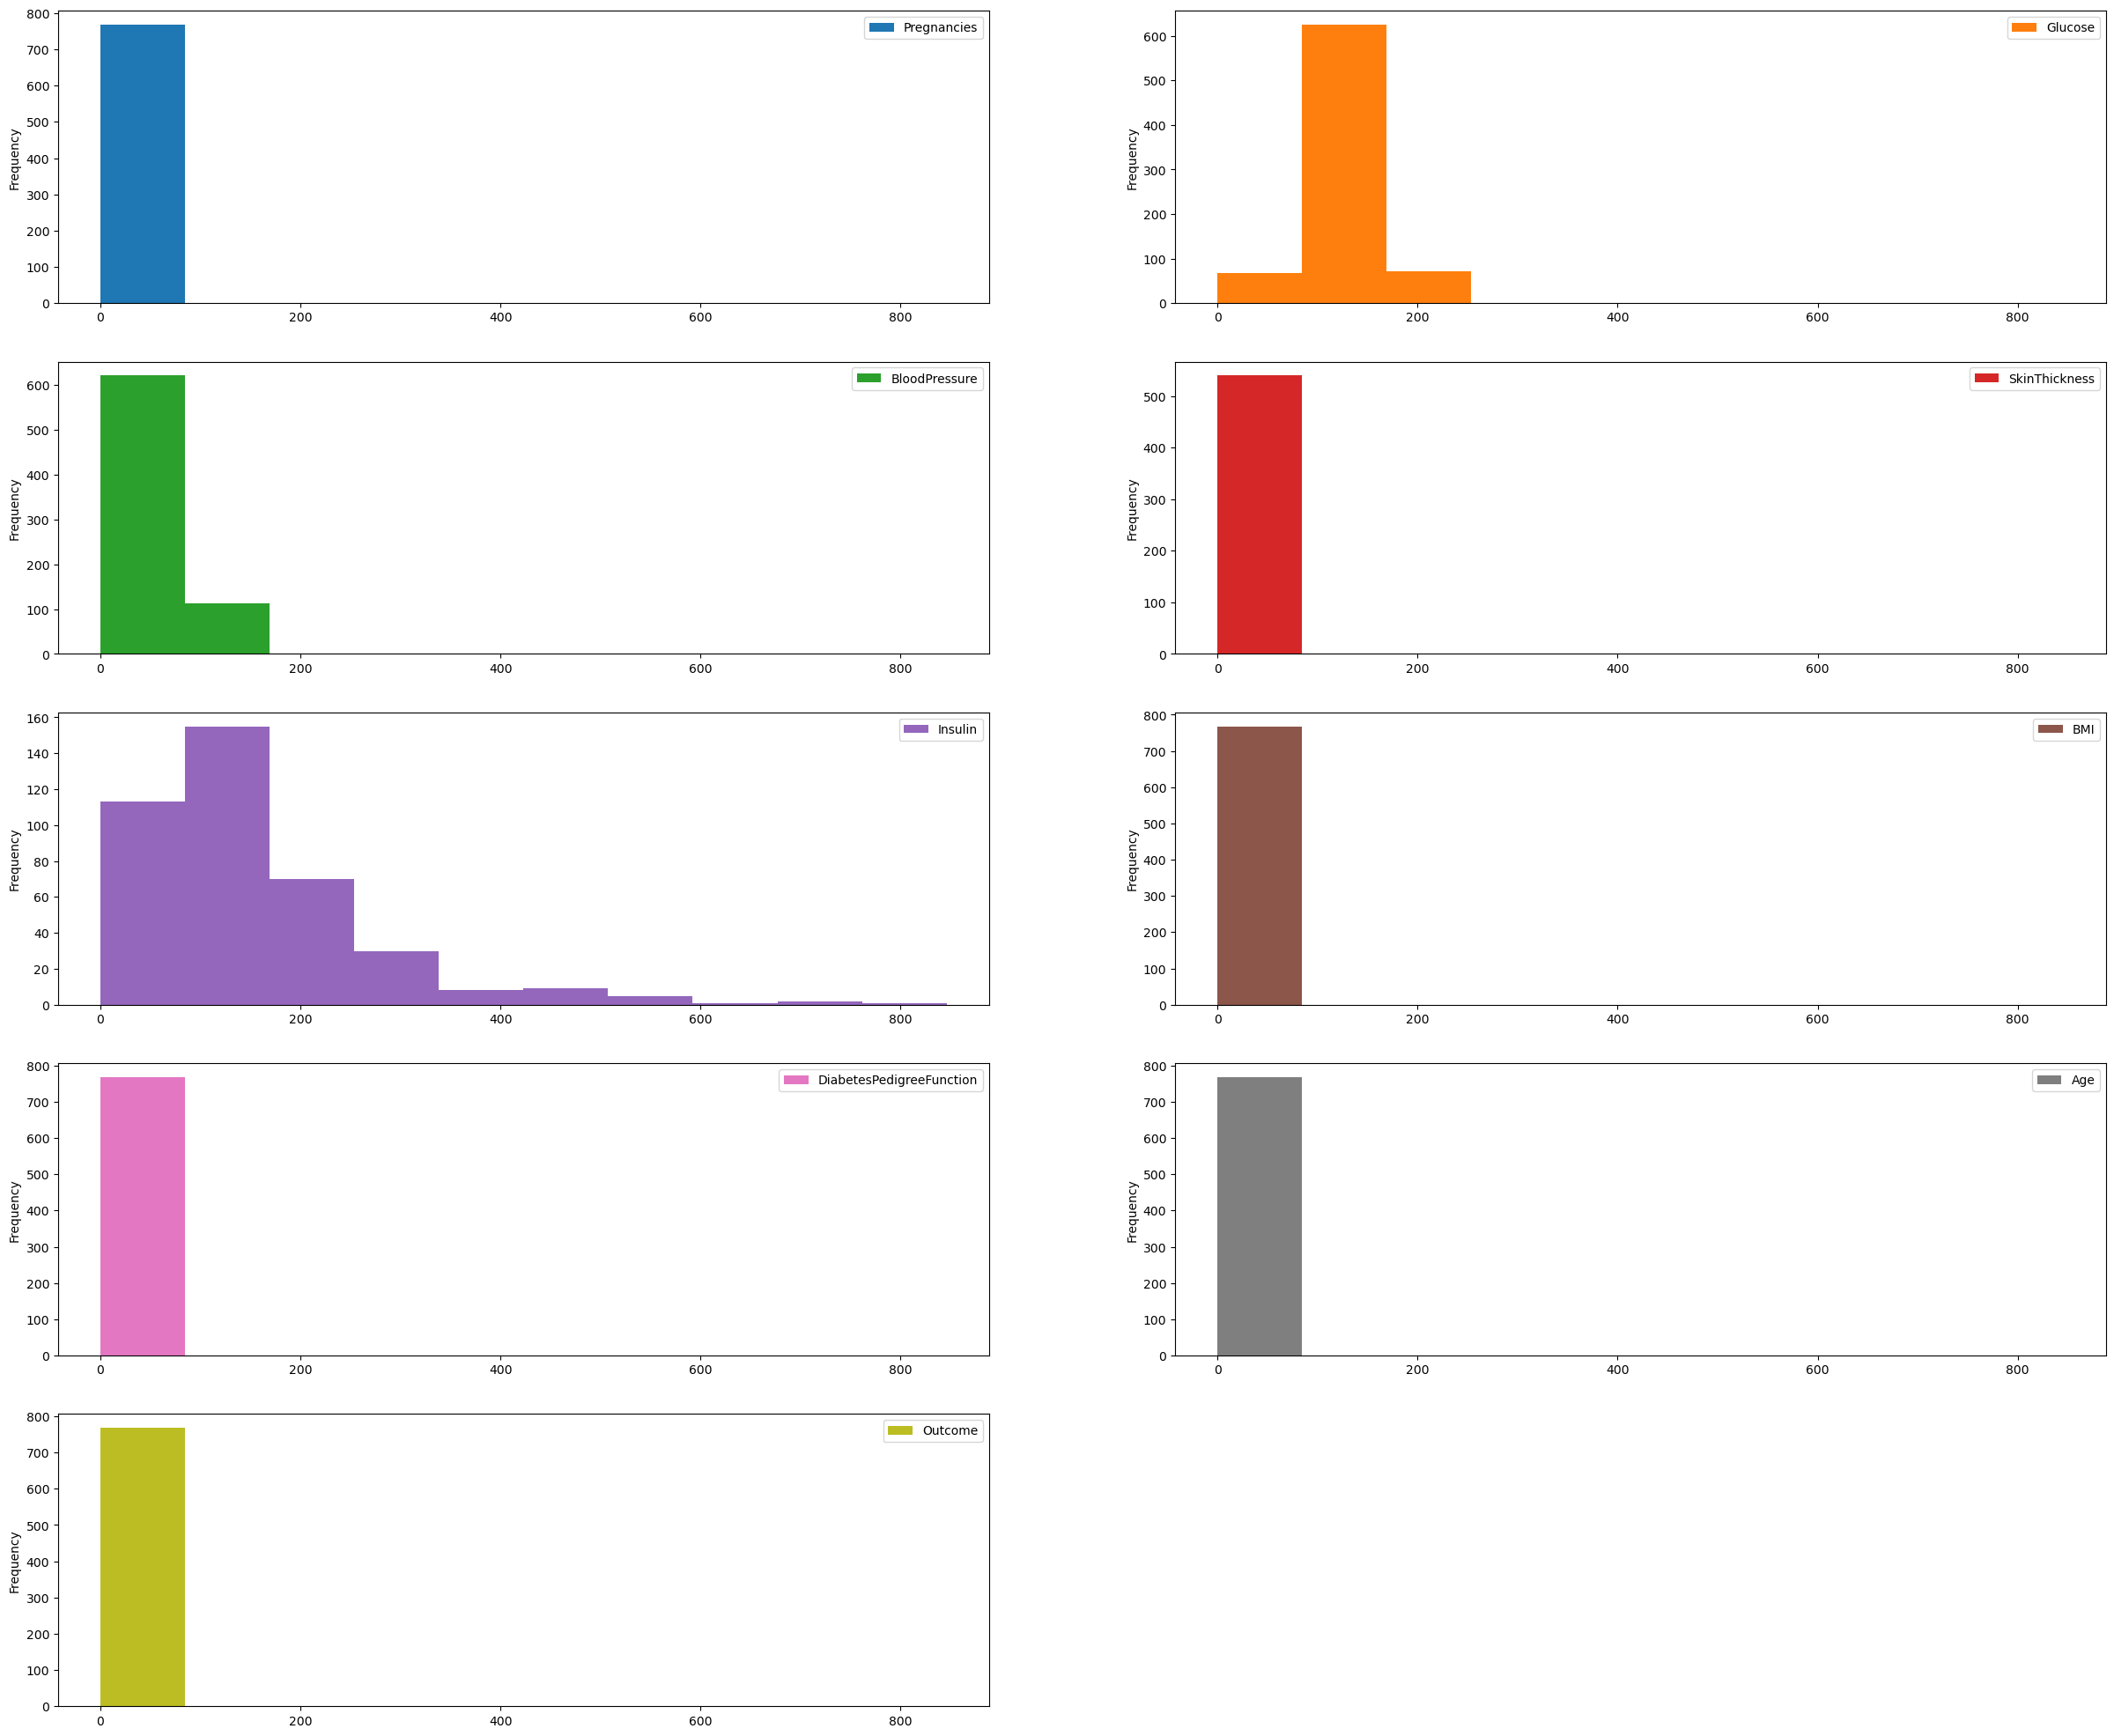

In [20]:
plt.rcParams['figure.figsize']= (30,25)
df.plot(kind='hist',bins=10,subplots=True,layout=(5,2),sharex=False, sharey=False)
plt.show() # the frequency which is y axis is different for all the plots 

I have done a mistake in question it was asked to show distribution before imputing or converting 0 to nan
but i did not did that so read question properly 

answer for the question  : Some features likes glucose,bmi,insulin etc have 0 values so i replaced this zero value with
nan then i imputed this nan with median(). Imputed it with median because it impute the all the value centrally . Some features were 
containg the extrems values which would get pulled toward that extrem value if we use mean as it take the average of all the value
and mode is used when we have categorical value because it give good frequent value for it 


Compare the distribution of Glucose for diabetic vs non-diabetic patients.

C:\Users\Asus\AppData\Local\Temp\ipykernel_5860\1179595758.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diabetic,label='diabetic',shade=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_5860\1179595758.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(non_diabetic,label='non_diabetic',shade=True)


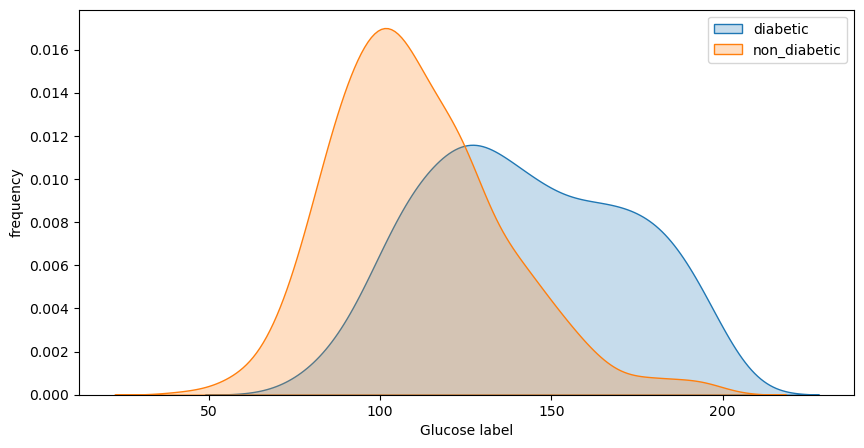

In [21]:
diabetic = df[df['Outcome']==1]['Glucose']
non_diabetic =  df[df['Outcome']==0]['Glucose']

fig,ax= plt.subplots (figsize=(10,5))
sns.kdeplot(diabetic,label='diabetic',shade=True)
sns.kdeplot(non_diabetic,label='non_diabetic',shade=True)
ax.set_xlabel('Glucose label')
ax.set_ylabel('frequency')
ax.legend()
plt.show()

ax helps to set the sns to plot the figure size according to us. For kde the plot size was not seting so i 
used ax then subplot.figure then with x, y , legend ax.set

The distribution plotshows that glucose level in diabetic individual are less compare to non_diabetic individual.
Additionally the glucose distribution for diabetic indivdual is positvely skewed while for non_diabetic it is 
normally distributed


Which three features show the strongest relationship with Outcome?

In [22]:
correlation=df.corr()

In [23]:
correlation['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.312038
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

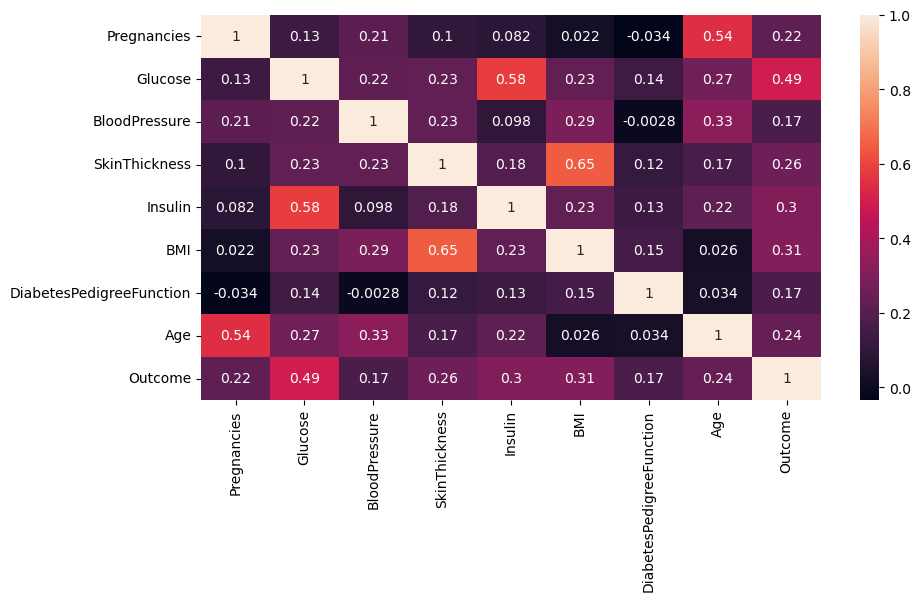

In [24]:
fig,ax= plt.subplots(figsize=(10,5))
sns.heatmap(correlation,annot=True)
plt.show()

three features show the strongest relationship with Outcome are Glucose,Insulin, BMI. Glucose shows highest relationahip
with Outcome. All other features show lower correlation with outcome hence, they dont affect to much to target variable.
Some features shows multicolinarity like pregnancies and age is 0.54, Glucose and insulin is 0.58, skinthickness and bmi is 0.65



In [25]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Is Age alone a strong predictor of diabetes in this dataset? Prove your answer using plots or statistics

Ans: No,age is not a strong predictor. The correlation of age and the outcome is very low about 0.24. Age shows 
multicolinarity with pregnancies so, alone age can not predict the daibetes we need to add other features with it


In [26]:
df['Insulin']= df['Insulin'].fillna(df['Insulin'].median())

In [27]:
df['SkinThickness']= df['SkinThickness'].fillna(df['SkinThickness'].median())

In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Do you need feature scaling for this dataset? Which models require it and why?

yes we need to do feature scaling . It requred logistic model. If features are not scalled 
the model will not be able to predict the data accuractely. The model like logistic regression need 
features to be scaled. If the features are not in same scale then model may focus more on the large number.
While the model like KNN, SVM are sensetive to scaling. 

Create a clean feature matrix X and target vector y.

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x = df.iloc[:,:-1] 


In [31]:
y = df.iloc[:,-1]
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

Would you drop any feature? If yes, justify with evidence. If no, explain why all are retained.

ans: No, I will not drop any features because all of them contribute in known if person is diabetes or not diabetes
Each features give different information about the diabetes so, all of them will help in predicting the model

Train a Logistic Regression model.

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=0)

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer


In [34]:
impute = SimpleImputer(strategy='median')
x_train_impute = impute.fit_transform(x_train)
x_test_impute = impute.transform(x_test)

Explain why Logistic Regression is suitable for this problem

Ans: Logistic Regression is suitable because this dataset is a supervised where the target variable is binary and notcontinuous.
The model like Linear Regression is not suitable for this dataset. Logistic model is used for binary outcomes and predict the probablity 
of having diabetes which make it a good choice for dataset.  
 

Evaluate the model using accuracy, precision, recall, and F1-score.

In [35]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_impute,y_train)
x_test_scaled = scaler.transform(x_test_impute)

In [36]:
x_train= pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test = pd.DataFrame (x_test_scaled)

In [37]:
model = LogisticRegression()
model.fit (x_train,y_train)

LogisticRegression()

In [38]:
from sklearn.metrics import *

In [39]:
y_pred =  model.predict(x_test)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91        51
           1       0.86      0.73      0.79        26

    accuracy                           0.87        77
   macro avg       0.87      0.84      0.85        77
weighted avg       0.87      0.87      0.87        77



In [41]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred)*100)

87.01298701298701


In [42]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8701298701298701
Precision: 0.8636363636363636
Recall: 0.7307692307692307
F1-score: 0.7916666666666666


In [43]:

cm= confusion_matrix(y_test,y_pred)
print('Confusion matirx\n\n',cm)

print("\nTrue Positives (TP):",cm[0,0])
print("\nFalse Negatives (FN):",cm[1,1])
print("\nFalse Positives (FP):",cm[0,1])
print("\nTrue Negatives (TN):", cm[1,0])


Confusion matirx

 [[48  3]
 [ 7 19]]

True Positives (TP): 48

False Negatives (FN): 19

False Positives (FP): 3

True Negatives (TN): 7


Recall (Sensitivity) – How many people who actually have diabetes did the model catch?

If recall is high, almost all diabetic patients are flagged.(identified)

This is most important in healthcare because missing a diabetic patient can be dangerous.

Precision: Out of all the people the model predicted as having diabetes, how many actually have diabetes?

High precision → Most of the flagged people really have diabetes.

Low precision → Many healthy people are wrongly flagged, which can cause unnecessary worry or extra tests.

High precision means fewer healthy people are told they might have diabetes.

Important to avoid unnecessary worry or extra tests.


Accuracy: Measures overall correctness (both diabetic and non-diabetic predictions). It can be misleading if the dataset is imbalanced, for example, if most patients are non-diabetic. A model predicting everyone as non-diabetic could still have high accuracy but would miss all actual diabetic patients.

F1-score: Combines precision and recall into one metric. It’s useful when you want a balance between catching all real positives (recall) and not over-predicting positives (precision). In healthcare, it’s a good overall measure if both false negatives and false positives have consequences.

In short:

Recall → most critical to avoid missing sick patients.

Precision → important to avoid unnecessary worry and testing.

Accuracy → less reliable if classes are imbalanced.

F1-score → useful summary metric for balancing recall and precision.

ques From a healthcare perspective, which metric matters most here and why?

In a healthcare context—like predicting diabetes—recall (sensitivity) usually matters the most.

Here’s why:

Recall measures how many actual positive cases (people who truly have diabetes) the model correctly identifies.

Missing a patient who actually has diabetes (a false negative) can be dangerous because they won’t get the treatment or lifestyle guidance they need.

On the other hand, a false positive (predicting diabetes when the person is healthy) is less risky—it might just lead to extra tests or check-ups.

So in this case, a model with high recall ensures that most diabetic patients are flagged, which is crucial for early diagnosis and intervention.